In [ ]:
# Import edelim
import torch
from torch import nn
import matplotlib.pyplot as plt
import numpy as np

# GPU kontrol edelim
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Data Hazirlayalim

# Parametreler
weight = 0.9
bias = 0.6

start = 1
stop = 100
step = 2

# Data
X = torch.arange(start, stop, step).unsqueeze(dim=1)
y = weight * X + bias

X[:3], y[:3]

(tensor([[1],
         [3],
         [5]]),
 tensor([[1.5000],
         [3.3000],
         [5.1000]]))

In [ ]:
# Train ve test icin ayiralim
train_size = int(0.8 * len(X))
test_size = len(X) - train_size
X_train = X[:train_size]
X_test = X[train_size:]
y_train = y[:train_size]
y_test = y[train_size:]

In [ ]:
# Tahminleri ve datalari gorsellestirelim
def plot_predictions(train_data = X_train,
                     test_data = X_test,
                     train_labels = y_train,
                     test_labels = y_test,
                     predictions = None):
  plt.figure(figsize=(10,7))

  plt.scatter(train_data, train_labels, c="r", s=4, label="Training data")
  plt.scatter(test_data, test_labels, c="b", s=4, label="Testing data")
  plt.scatter(test_data, predictions, c="g", s=4, label="Predictions")

  plt.legend(prop={"size":14});

In [ ]:
# Model olusturalim
class Kendimodelim(nn.Module):
  def __init__(self):
    super().__init__()
    self.weight = nn.Parameter(torch.randn(1,
                                           requires_grad = True,
                                           dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad = True,
                                         dtype = torch.float))
  def forward(self, x):
    return self.weight * x + self.bias

In [ ]:
# Random seed olusturalim
torch.manual_seed(44)

# Modeli belirleyelim
model = Kendimodelim()

# Model ile tahmin olusturalim
with torch.inference_mode():
  y_preds = model(X_test)

In [ ]:
# modelimizin state dict i goruntuleyelim
model.state_dict()

OrderedDict([('weight', tensor([0.0589])), ('bias', tensor([-1.3945]))])

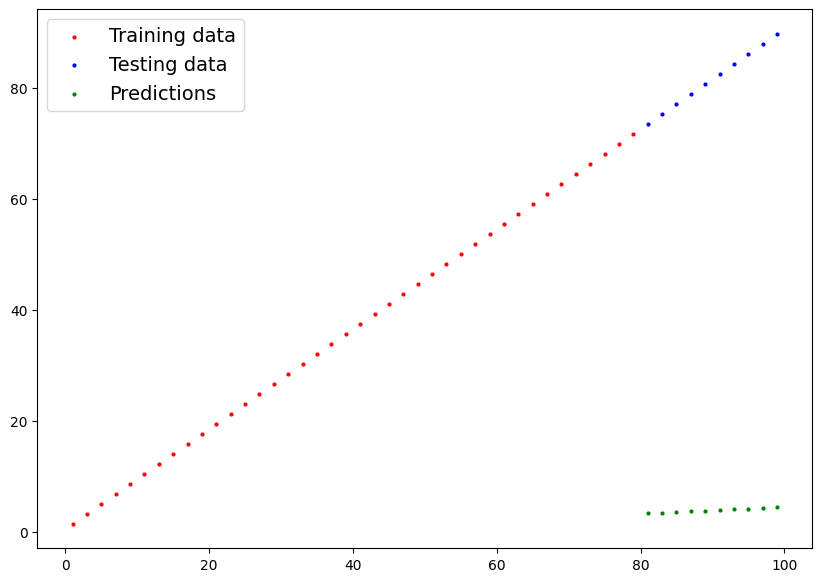

In [ ]:
plot_predictions(predictions= y_preds)

In [ ]:
# Modelimizi egitelim
def train_model(lr):


  loss_func = nn.L1Loss()

  optimizer = torch.optim.SGD(params = model.parameters(),
                              lr = lr)

  epochs = 100

  epoch_count = []
  train_loss_values = []
  test_loss_values = []


  for epoch in range(epochs):

    # train moduna alalim
    model.train()

    # tahminleri alalim
    y_pred = model(X_train)

    # train loss hesaplayalim
    loss = loss_func(y_pred, y_train)

    # optimizer tekrar calisacagi icin sifirlayalim
    optimizer.zero_grad()

    # loss da cikan degerelere turev islemi alalim matematigini hesaplayalim
    loss.backward()

    # hesaplanan degerlerle birlikte parametrelerimizi guncelleyelim
    optimizer.step()


    # test moduna alalim
    model.eval()

    # egitim yapmayacagimiz icin tahmin moduna alalim
    with torch.inference_mode():

      # tahmin uretelim
      test_pred = model(X_test)

      # test loss hesaplayalim
      test_loss = loss_func(test_pred, y_test)

    # verilerimizi yazdiralim
    if epoch % 10 == 0:
      epoch_count.append(epoch)
      train_loss_values.append(loss)
      test_loss_values.append(test_loss)
      print(f"Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}")
      print("--------------------------------------------------------")

In [ ]:
train_model(lr = 0.001)

Epoch: 0 | Loss: 12.795411109924316 | Test loss: 26.630563735961914
--------------------------------------------------------
Epoch: 10 | Loss: 1.1823365688323975 | Test loss: 0.41291579604148865
--------------------------------------------------------
Epoch: 20 | Loss: 0.6056951880455017 | Test loss: 0.31318360567092896
--------------------------------------------------------
Epoch: 30 | Loss: 1.186319351196289 | Test loss: 0.4232726991176605
--------------------------------------------------------
Epoch: 40 | Loss: 0.606695830821991 | Test loss: 0.302825927734375
--------------------------------------------------------
Epoch: 50 | Loss: 1.1903005838394165 | Test loss: 0.4336303770542145
--------------------------------------------------------
Epoch: 60 | Loss: 0.8122865557670593 | Test loss: 0.17546996474266052
--------------------------------------------------------
Epoch: 70 | Loss: 1.1942838430404663 | Test loss: 0.4439834654331207
--------------------------------------------------

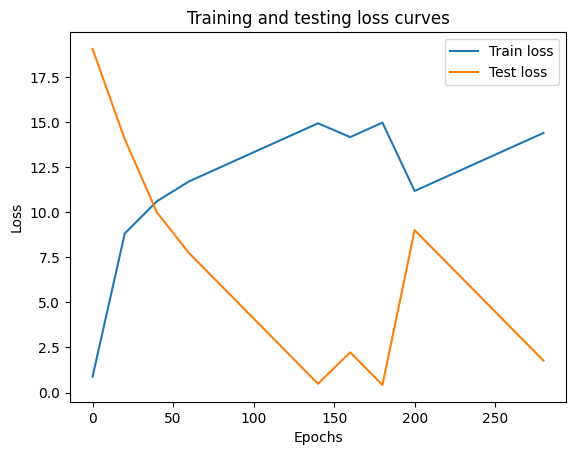

In [ ]:
plt.plot(epoch_count, np.array(torch.tensor(train_loss_values).numpy()), label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and testing loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend();